### Подготовка окружения и загрузка данных

In [105]:
from pathlib import Path
import shutil
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    precision_recall_curve
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers


In [106]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [107]:
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

In [108]:
import json
import joblib

In [109]:
!pip -q install mlflow

In [110]:
import mlflow

In [111]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [112]:
tabular_train = pd.read_csv("tabular_train.csv")
tabular_val = pd.read_csv("tabular_val.csv")

In [113]:
tabular_test = pd.read_csv("tabular_test.csv")

text_train = pd.read_csv("text_train.csv")
text_val = pd.read_csv("text_val.csv")
text_test = pd.read_csv("text_test.csv")

tabular_full = pd.read_csv("tabular_full.csv")
text_full = pd.read_csv("text_full.csv")

In [114]:
print("tabular full:", tabular_full.shape)
print("tabular train:", tabular_train.shape)
print("tabular val:", tabular_val.shape)
print("tabular test:", tabular_test.shape)

print("\ntext full:", text_full.shape)
print("text train:", text_train.shape)
print("text val:", text_val.shape)
print("text test:", text_test.shape)

tabular full: (5874, 40)
tabular train: (4111, 40)
tabular val: (881, 40)
tabular test: (882, 40)

text full: (5218, 4)
text train: (3652, 4)
text val: (783, 4)
text test: (783, 4)


## Проверим данные перед обучением

Перед обучением ещё раз проверим баланс классов и убедимся, что в табличную модель не попали признаки, которые напрямую раскрывают target

In [115]:
target_col= "high_revenue_efficiency"

print("Tabular train balance:")
display(tabular_train[target_col].value_counts(normalize=True))

print("Text train balance:")
display(text_train[target_col].value_counts(normalize=True))

Tabular train balance:


,proportion
high_revenue_efficiency,
1,0.511311
0,0.488689


Text train balance:


,proportion
high_revenue_efficiency,
1,0.575575
0,0.424425


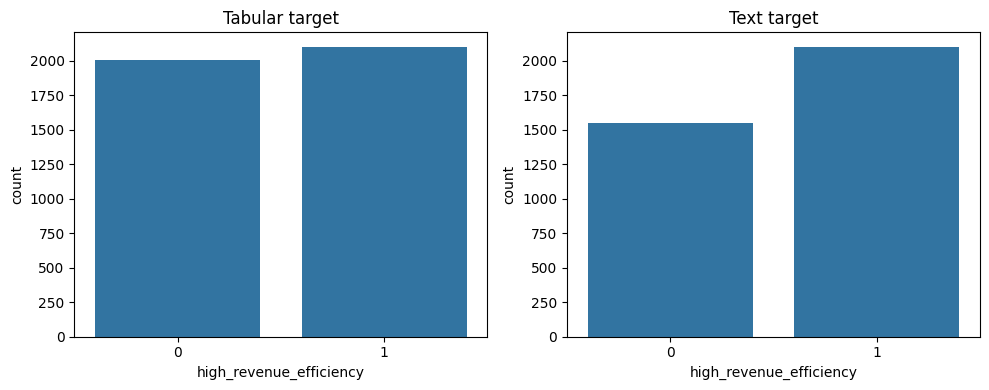

In [116]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(data=tabular_train, x=target_col, ax=axes[0])
axes[0].set_title("Tabular target")

sns.countplot(data=text_train, x=target_col, ax=axes[1])
axes[1].set_title("Text target")

plt.tight_layout()
plt.show()

In [117]:
leakage_check = [
    "estimated_revenue_l365d",
    "revenue_per_price",
    "unavailable_rate",
    "weekday_unavailable_rate",
    "weekend_unavailable_rate",
]

[col for col in leakage_check if col in tabular_train.columns]

[]

Баланс классов нормальный, табличная часть почти 50/50, текстовая немного смещена, но без критичного дисбаланса. утечки тоже нет, всё ок

## Табличные признаки

категориальные признаки закодируем через OneHotEncoder, числовые признаки нормализуем через StandardScaler

In [118]:
X_train_raw = tabular_train.drop(columns=["listing_id", target_col])
X_val_raw = tabular_val.drop(columns=["listing_id", target_col])
X_test_raw = tabular_test.drop(columns=["listing_id", target_col])

y_train = tabular_train[target_col].values
y_val = tabular_val[target_col].values
y_test = tabular_test[target_col].values

In [119]:
cat_cols = X_train_raw.select_dtypes(include="object").columns.tolist()
num_cols = X_train_raw.select_dtypes(exclude="object").columns.tolist()

print("numeric:", len(num_cols))
print("categorical:", len(cat_cols))
print(cat_cols)

numeric: 34
categorical: 4
['host_response_time', 'neighbourhood_cleansed', 'property_type_grouped', 'room_type']


In [120]:
try:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse=False)

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", one_hot),
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
])

In [121]:
X_train = preprocessor.fit_transform(X_train_raw)
X_val = preprocessor.transform(X_val_raw)
X_test = preprocessor.transform(X_test_raw)

X_train.shape, X_val.shape, X_test.shape

((4111, 86), (881, 86), (882, 86))

## Обучение MLP-моделей

Для табличной части обучим четыре варианта полносвязной нейронной сети:

- простая MLP         
- более глубокая MLP       
- MLP с BatchNorm и Dropout.    
- MLP с L2-регуляризацией

посмотрим как глубина сети и регуляризация влияют на качество

In [122]:
tf.random.set_seed(RANDOM_STATE)

X_train = X_train.astype("float32")
X_val = X_val.astype("float32")
X_test = X_test.astype("float32")

y_train = y_train.astype("float32")
y_val = y_val.astype("float32")
y_test = y_test.astype("float32")

In [123]:
def make_small_mlp(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])

    return model

In [124]:
def make_deep_mlp(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])

    return model

In [125]:
def make_regularized_mlp(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])

    return model

In [126]:
def make_l2_mlp(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001),
        ),
        layers.Dropout(0.2),
        layers.Dense(
            64,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001),
        ),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])

    return model

In [127]:
def compile_model(model):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc"),
        ],
    )

    return model

In [128]:
def train_mlp(model, model_name):
    print(f"Training {model_name}")

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=7,
        restore_best_weights=True,
    )

    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-5,
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=60,
        batch_size=64,
        callbacks=[early_stop, reduce_lr],
        verbose=1,
    )

    return history

Используем early stopping по validation AUC, чтобы модели не обучались лишние эпохи и не переобучались слишком сильно

In [129]:
input_dim = X_train.shape[1]

tabular_models = {
    "small_mlp": compile_model(make_small_mlp(input_dim)),
    "deep_mlp": compile_model(make_deep_mlp(input_dim)),
    "batchnorm_dropout_mlp": compile_model(make_regularized_mlp(input_dim)),
    "l2_dropout_mlp": compile_model(make_l2_mlp(input_dim)),
}

In [130]:
tabular_histories = {}

for model_name, model in tabular_models.items():
    tabular_histories[model_name] = train_mlp(model, model_name)

Training small_mlp
Epoch 1/60
65/65 ━━━━━━━━━━━━━━━━━━━━ 14s 121ms/step - accuracy: 0.6767 - auc: 0.7303 - loss: 0.6009 - precision: 0.7286 - recall: 0.5861 - val_accuracy: 0.7208 - val_auc: 0.7767 - val_loss: 0.5626 - val_precision: 0.7887 - val_recall: 0.6208 - learning_rate: 0.0010
Epoch 2/60
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7429 - auc: 0.8021 - loss: 0.5289 - precision: 0.8057 - recall: 0.6551 - val_accuracy: 0.7344 - val_auc: 0.8012 - val_loss: 0.5341 - val_precision: 0.8056 - val_recall: 0.6341 - learning_rate: 0.0010
Epoch 3/60
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7558 - auc: 0.8246 - loss: 0.5019 - precision: 0.8218 - recall: 0.6670 - val_accuracy: 0.7446 - val_auc: 0.8122 - val_loss: 0.5189 - val_precision: 0.8229 - val_recall: 0.6386 - learning_rate: 0.0010
Epoch 4/60
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7619 - auc: 0.8381 - loss: 0.4842 - precision: 0.8286 - recall: 0.6736 - val_accuracy: 0.7401 - val_auc: 0.8184 - val_lo

In [131]:
def evaluate_model(model, X, y):
    y_proba = model.predict(X).ravel()
    y_pred = (y_proba >= 0.5).astype(int)

    return {
        "accuracy": accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred),
        "recall": recall_score(y, y_pred),
        "f1": f1_score(y, y_pred),
        "roc_auc": roc_auc_score(y, y_proba),
    }

In [132]:
tabular_results = []

for model_name, model in tabular_models.items():
    val_metrics = evaluate_model(model, X_val, y_val)
    test_metrics = evaluate_model(model, X_test, y_test)

    row = {"model": model_name}

    for metric_name, value in val_metrics.items():
        row[f"val_{metric_name}"] = value

    for metric_name, value in test_metrics.items():
        row[f"test_{metric_name}"] = value

    tabular_results.append(row)

tabular_results = pd.DataFrame(tabular_results)
tabular_results.sort_values("val_roc_auc", ascending=False)

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


,model,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
3,l2_dropout_mlp,0.748014,0.843844,0.623060,0.716837,0.836554,0.748299,0.837758,0.629712,0.718987,0.820811
2,batchnorm_dropout_mlp,0.752554,0.843658,0.634146,0.724051,0.835853,0.735828,0.822485,0.616408,0.704689,0.809210
1,deep_mlp,0.761635,0.837535,0.662971,0.740099,0.833646,0.743764,0.798408,0.667406,0.727053,0.818254
0,small_mlp,0.751419,0.835260,0.640798,0.725220,0.831671,0.740363,0.815341,0.636364,0.714819,0.820888


In [133]:
def plot_training_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history["loss"], label="train")
    axes[0].plot(history.history["val_loss"], label="val")
    axes[0].set_title(f"{model_name}: loss")
    axes[0].legend()

    axes[1].plot(history.history["auc"], label="train")
    axes[1].plot(history.history["val_auc"], label="val")
    axes[1].set_title(f"{model_name}: AUC")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

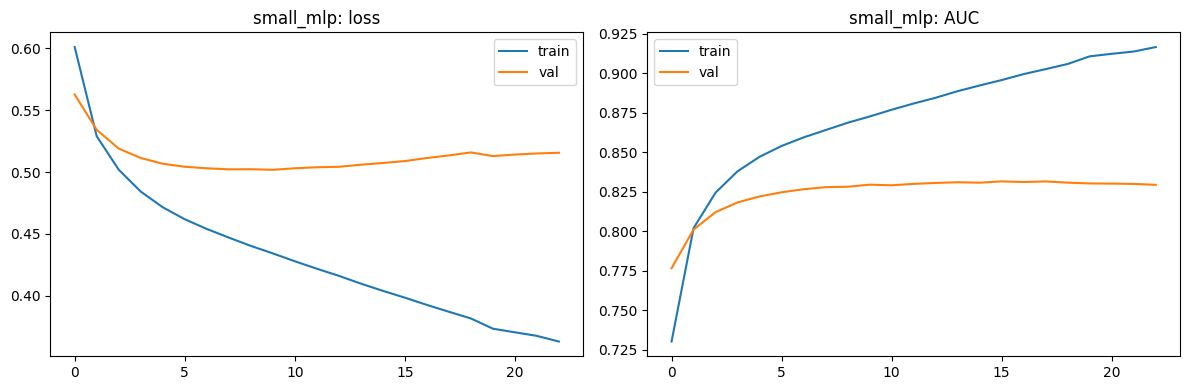

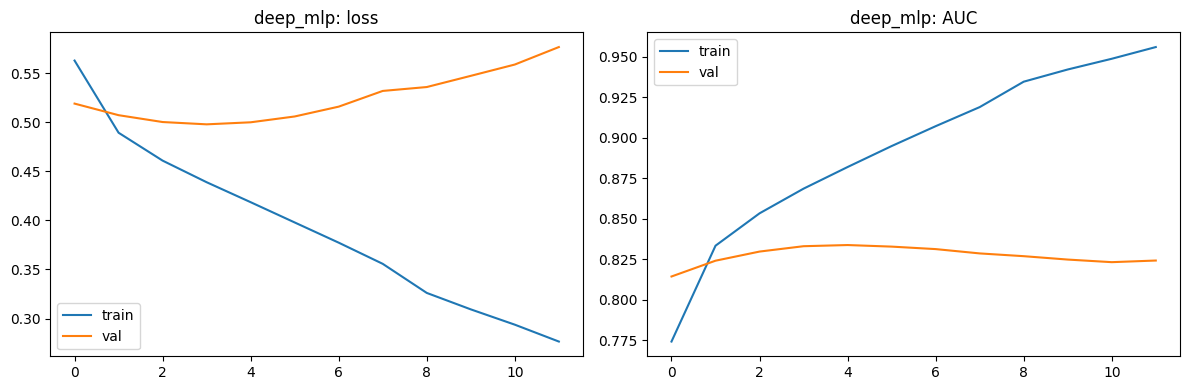

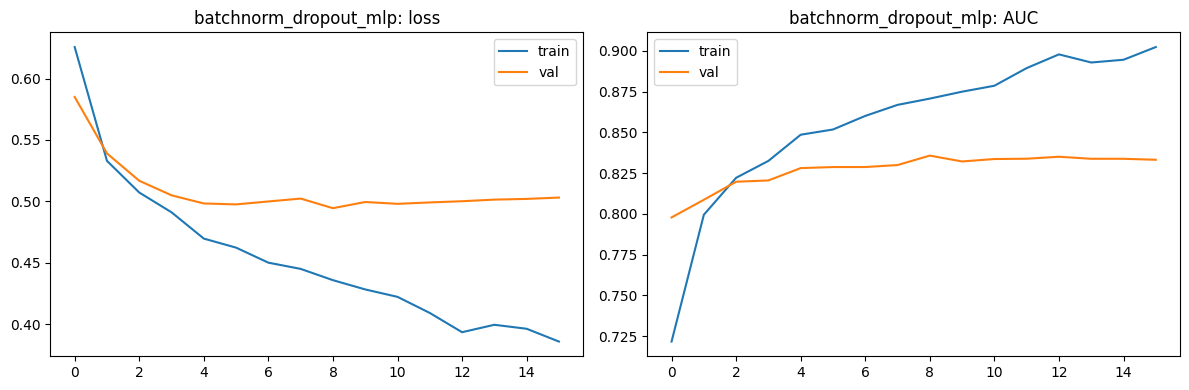

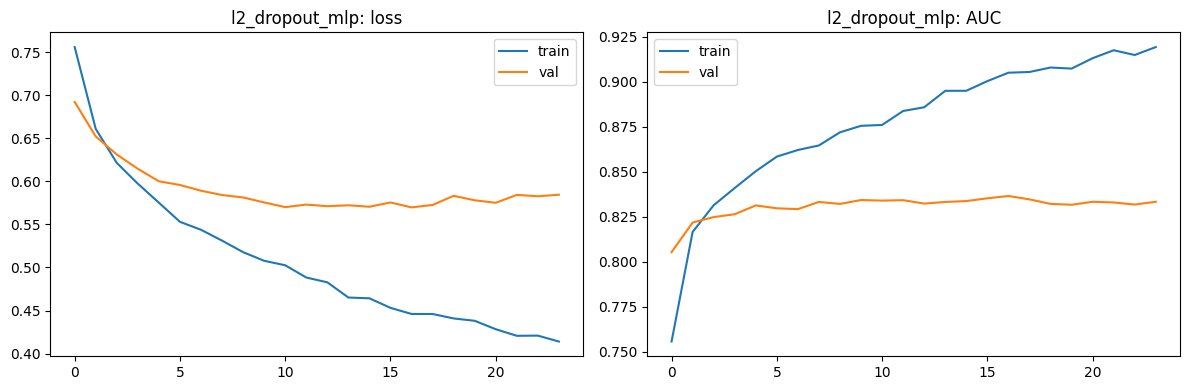

In [134]:
for model_name, history in tabular_histories.items():
    plot_training_history(history, model_name)

In [135]:
best_tabular_model_name = tabular_results.sort_values(
    "val_roc_auc",
    ascending=False
).iloc[0]["model"]

best_tabular_model = tabular_models[best_tabular_model_name]

best_tabular_model_name

'l2_dropout_mlp'

In [136]:
# найдём более компромиссный порог, чтобы улучшить баланс precision и recall

val_proba = best_tabular_model.predict(X_val).ravel()

precision_vals, recall_vals, thresholds = precision_recall_curve(y_val, val_proba)

f1_vals = 2 * precision_vals * recall_vals / (precision_vals + recall_vals + 1e-8)

best_idx = np.argmax(f1_vals[:-1])
best_threshold = thresholds[best_idx]

best_threshold, f1_vals[best_idx]

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


(np.float32(0.2981498), np.float64(0.76102563605367))

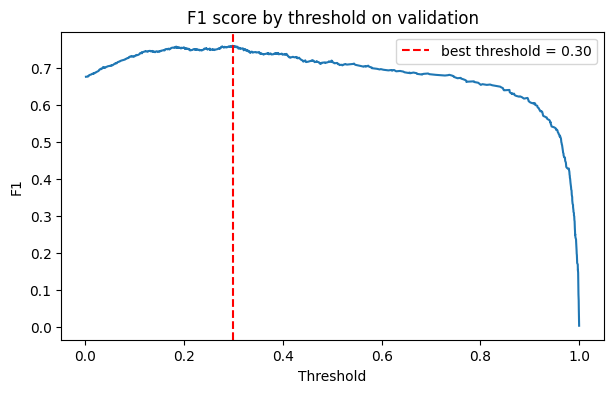

In [137]:
plt.figure(figsize=(7, 4))
plt.plot(thresholds, f1_vals[:-1])
plt.axvline(best_threshold, color="red", linestyle="--", label=f"best threshold = {best_threshold:.2f}")
plt.title("F1 score by threshold on validation")
plt.xlabel("Threshold")
plt.ylabel("F1")
plt.legend()
plt.show()

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


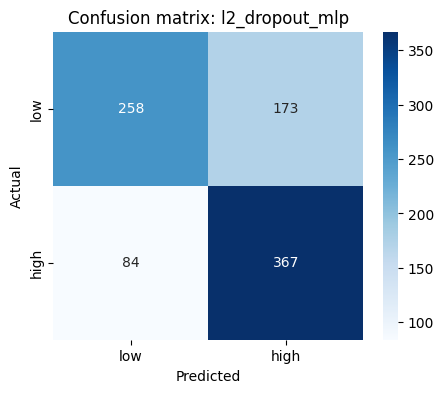

TN: 258
FP: 173
FN: 84
TP: 367


In [138]:
y_test_proba = best_tabular_model.predict(X_test).ravel()
y_test_pred = (y_test_proba >= best_threshold).astype(int)

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["low", "high"],
    yticklabels=["low", "high"],
)
plt.title(f"Confusion matrix: {best_tabular_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

tn, fp, fn, tp = cm.ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

In [139]:
best_threshold_metrics = {
    "model": best_tabular_model_name,
    "threshold": best_threshold,
    "test_accuracy": accuracy_score(y_test, y_test_pred),
    "test_precision": precision_score(y_test, y_test_pred),
    "test_recall": recall_score(y_test, y_test_pred),
    "test_f1": f1_score(y_test, y_test_pred),
    "test_roc_auc": roc_auc_score(y_test, y_test_proba),
}

best_threshold_metrics

{'model': 'l2_dropout_mlp',
 'threshold': np.float32(0.2981498),
 'test_accuracy': 0.7086167800453514,
 'test_precision': 0.6796296296296296,
 'test_recall': 0.8137472283813747,
 'test_f1': 0.7406659939455096,
 'test_roc_auc': np.float64(0.8208106759405497)}

После подбора threshold качество оцениваем на тестовых данных. тут важно что ROC-AUC не зависит от порога, а accuracy, precision, recall и F1 уже считаются с новым

In [140]:
local_artifacts_dir = Path("/content/tabular_artifacts")
local_artifacts_dir.mkdir(parents=True, exist_ok=True)

drive_tabular_dir = drive_dir / "artifacts" / "tabular"
drive_tabular_dir.mkdir(parents=True, exist_ok=True)

In [141]:
best_threshold_metrics_clean = {
    key: float(value) if isinstance(value, (np.floating, np.integer)) else value
    for key, value in best_threshold_metrics.items()
}

best_threshold_metrics_clean["threshold"] = float(best_threshold)

In [142]:
best_tabular_model.save(local_artifacts_dir / "best_tabular_model.keras")

joblib.dump(preprocessor, local_artifacts_dir / "tabular_preprocessor.joblib")

tabular_results.to_csv(
    local_artifacts_dir / "tabular_model_comparison.csv",
    index=False
)

with open(local_artifacts_dir / "best_tabular_metrics.json", "w") as f:
    json.dump(best_threshold_metrics_clean, f, indent=4)

In [143]:
for file_path in local_artifacts_dir.iterdir():
    shutil.copy2(file_path, drive_tabular_dir / file_path.name)

list(drive_tabular_dir.iterdir())

[PosixPath('MyDrive/artifacts/tabular/tabular_preprocessor.joblib'),
 PosixPath('MyDrive/artifacts/tabular/batchnorm_dropout_mlp_history.csv'),
 PosixPath('MyDrive/artifacts/tabular/tabular_model_comparison.csv'),
 PosixPath('MyDrive/artifacts/tabular/l2_dropout_mlp_history.csv'),
 PosixPath('MyDrive/artifacts/tabular/deep_mlp.keras'),
 PosixPath('MyDrive/artifacts/tabular/small_mlp.keras'),
 PosixPath('MyDrive/artifacts/tabular/deep_mlp_history.csv'),
 PosixPath('MyDrive/artifacts/tabular/best_tabular_model.keras'),
 PosixPath('MyDrive/artifacts/tabular/l2_dropout_mlp.keras'),
 PosixPath('MyDrive/artifacts/tabular/best_tabular_metrics.json'),
 PosixPath('MyDrive/artifacts/tabular/small_mlp_history.csv'),
 PosixPath('MyDrive/artifacts/tabular/batchnorm_dropout_mlp.keras')]

Сохранили лучшую табличную модель, preprocessor, таблицу сравнения моделей и финальные test-метрики

### mlflow

In [144]:
import os

os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

mlflow_dir = Path("/content/mlruns")
mlflow_dir.mkdir(parents=True, exist_ok=True)

mlflow.set_tracking_uri(f"file://{mlflow_dir}")
mlflow.set_experiment("airbnb_tabular_mlp")

<Experiment: artifact_location='file:///content/mlruns/255807054329641319', creation_time=1781559765269, effective_trace_archival_retention=None, experiment_id='255807054329641319', last_update_time=1781559765269, lifecycle_stage='active', name='airbnb_tabular_mlp', tags={}, trace_location=None, workspace='default'>

In [145]:
if mlflow.active_run():
    mlflow.end_run()

In [146]:
for row_idx in range(len(tabular_results)):
    row = tabular_results.iloc[row_idx]

    model_name = row["model"]
    model = tabular_models[model_name]
    history = tabular_histories[model_name]

    with mlflow.start_run(run_name=model_name):
        mlflow.log_param("model_name", model_name)
        mlflow.log_param("target", target_col)
        mlflow.log_param("input_dim", X_train.shape[1])
        mlflow.log_param("batch_size", 64)

        for metric_name in tabular_results.columns:
            if metric_name != "model":
                mlflow.log_metric(metric_name, float(row[metric_name]))

        history_df = pd.DataFrame(history.history)
        history_path = local_artifacts_dir / f"{model_name}_history.csv"
        history_df.to_csv(history_path, index=False)

        model_path = local_artifacts_dir / f"{model_name}.keras"
        model.save(model_path)

        mlflow.log_artifact(str(history_path))
        mlflow.log_artifact(str(model_path))

In [147]:
with mlflow.start_run(run_name="best_tabular_model_summary"):
    mlflow.log_param("best_model", best_tabular_model_name)
    mlflow.log_param("best_threshold", float(best_threshold))
    mlflow.log_param("target", target_col)

    for metric_name, value in best_threshold_metrics_clean.items():
        if metric_name != "model":
            mlflow.log_metric(metric_name, float(value))

    mlflow.log_artifact(str(local_artifacts_dir / "best_tabular_model.keras"))
    mlflow.log_artifact(str(local_artifacts_dir / "tabular_preprocessor.joblib"))
    mlflow.log_artifact(str(local_artifacts_dir / "tabular_model_comparison.csv"))
    mlflow.log_artifact(str(local_artifacts_dir / "best_tabular_metrics.json"))

In [148]:
drive_mlruns_dir = drive_dir/ "mlruns_tabular"

if drive_mlruns_dir.exists():
    shutil.rmtree(drive_mlruns_dir)

shutil.copytree(mlflow_dir, drive_mlruns_dir)

drive_mlruns_dir

PosixPath('MyDrive/mlruns_tabular')

In [149]:
print("tabular artifacts:", drive_tabular_dir)
print(" mlflow logs:", drive_mlruns_dir)

print("\nSaved artifacts:")
for file_path in sorted(drive_tabular_dir.iterdir()):
    print(file_path.name)

tabular artifacts: MyDrive/artifacts/tabular
 mlflow logs: MyDrive/mlruns_tabular

Saved artifacts:
batchnorm_dropout_mlp.keras
batchnorm_dropout_mlp_history.csv
best_tabular_metrics.json
best_tabular_model.keras
deep_mlp.keras
deep_mlp_history.csv
l2_dropout_mlp.keras
l2_dropout_mlp_history.csv
small_mlp.keras
small_mlp_history.csv
tabular_model_comparison.csv
tabular_preprocessor.joblib


## Итого:

В табличной части обучили 4 MLP-модели: простую MLP, более глубокую, с BatchNorm и droput и с L2-регуляризацией. Лучшая по validation ROC-AUC `l2_dropout_mlp`.

ROC-AUC = 0.821
итоговые метрики после подбора threshold на validation: accuracy = 0.709, precision = 0.680, recall = 0.814 и F1 = 0.741

Threshold получился ниже стандартного 0.5, потому что мы подбирали его по максимуму F1 на валидации. при пороге 0.5 модель была более осторожной и чаще пропускала успешные объявления. А более низкий threshold позволяет находить больше потенциально коммерчески эффективных объектов, т.е. повышает recall, что бизнесово нам больше подходит -> лучше отправить на дополнительный анализ больше перспективных объявлений, чем пропустить значимую часть успешных.

При этом precision остаётся всё равно нормальным.(вообще тут компромисс и можно выбрать что для нас важнее, но ещё раз подчеркну что в текущем варианте бизнесово логичнее as is)

эксперименты залогированы в MLflow. лучшая модель, preprocessor, таблица сравнения и финальные метрики сохранены как артефакты.